## Prepare Dataset

In [2]:
import pandas as pd
df = pd.read_csv("Weather_Integrated_Dataset.csv")
# 1. Ensure the 'Datetime' column is formatted as actual pandas datetime objects
df['Datetime'] = pd.to_datetime(df['Datetime'])

# 2. Filter the dataframe to keep only rows >= your target start time
start_time = '2026-06-22 12:48:00'
df = df[df['Datetime'] >= start_time]

# 3. Reset the index so your row numbers start cleanly at 0 again
df = df.reset_index(drop=True)

# Verify the result
df.head()


,Datetime,Hour,DayName,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-22 12:48:05,12,Monday,0,0,24.8,65.0,26.380000,91.34115,0.0,98.200000,3.898234
1,2026-06-22 12:49:05,12,Monday,0,0,24.8,64.5,26.369167,91.42090,0.0,98.183334,3.873381
2,2026-06-22 12:50:05,12,Monday,0,0,24.9,63.9,26.358334,91.50064,0.0,98.166664,3.848528
3,2026-06-22 12:51:05,12,Monday,0,0,24.9,63.4,26.347500,91.58039,0.0,98.150000,3.823675
4,2026-06-22 12:52:05,12,Monday,0,0,24.9,62.8,26.336666,91.66014,0.0,98.133330,3.798822


In [3]:
import pandas as pd

# 1. Ensure Datetime is a proper datetime object and set it as the index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# 2. Isolate only the continuous numerical columns that make sense to average
numerical_cols = [
    'IndoorTemp', 'IndoorHumidity',
    'OutdoorTemp', 'OutdoorHumidity',
    'Rain', 'CloudCover', 'WindSpeed'
]

# 3. Downsample to 5-minute chunks ('5min') and calculate the mean
df_5min = df[numerical_cols].resample('5min').mean()

# Drop any blank rows (in case there were missing chunks in your original data)
df_5min = df_5min.dropna()

# 4. Rebuild the time and calendar features based on the new 5-minute timestamps
df_5min['Hour'] = df_5min.index.hour
df_5min['DayOfWeek'] = df_5min.index.dayofweek # Monday=0, Sunday=6
df_5min['DayName'] = df_5min.index.day_name()
df_5min['Weekend'] = df_5min['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# 5. Reset the index so 'Datetime' becomes a normal column again
df_5min = df_5min.reset_index()

# Check the results
df_5min.head()

,Datetime,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed,Hour,DayOfWeek,DayName,Weekend
0,2026-06-22 12:45:00,24.80,64.75,26.374583,91.381025,0.0,98.191667,3.885807,12,0,Monday,0
1,2026-06-22 12:50:00,24.86,63.02,26.336666,91.660136,0.0,98.133333,3.798822,12,0,Monday,0
2,2026-06-22 12:55:00,24.70,61.68,26.282500,92.058876,0.0,98.050000,3.674558,12,0,Monday,0
3,2026-06-22 13:00:00,24.62,62.90,26.238333,92.362474,0.0,97.766666,3.607138,13,0,Monday,0
4,2026-06-22 13:05:00,24.66,62.20,26.209167,92.523360,0.0,97.183333,3.624982,13,0,Monday,0


In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Calculate rate of change for temperature and humidity
df_5min['dT'] = df_5min['IndoorTemp'].diff().fillna(0)
df_5min['dH'] = df_5min['IndoorHumidity'].diff().fillna(0)

# Calculate the Thermal Gradient
df_5min['Gradient'] = df_5min['OutdoorTemp'] - df_5min['IndoorTemp']

# ==========================================
# 2. SCHEDULE MASKING & K-MEANS CLUSTERING
# ==========================================
# Default everything to OFF (0) initially
df_5min['AC_State'] = 0

# Define active business hours for the initial ML guess
active_days = df_5min['DayOfWeek'].isin([0, 2, 4])
active_hours = (df_5min['Hour'] >= 9) & (df_5min['Hour'] < 18)
uncertain_mask = active_days & active_hours

# Run K-Means only on the uncertain times
uncertain_data = df_5min[uncertain_mask].copy()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
features = ['dT', 'dH', 'Gradient']
uncertain_data['cluster'] = kmeans.fit_predict(uncertain_data[features])

# Identify the AC ON cluster (steepest temperature drop)
on_cluster_index = np.argmin(kmeans.cluster_centers_[:, 0])
uncertain_data['Predicted_AC'] = (uncertain_data['cluster'] == on_cluster_index).astype(int)

# Map ML predictions back to the main dataframe
df_5min.loc[uncertain_mask, 'AC_State'] = uncertain_data['Predicted_AC']

# ==========================================
# 3. THE FIX: ROBUST PHYSICS OVERRIDES
# ==========================================
# Override A: The Thermodynamic Limit (Accounts for DHT22 and API Error)
# 1. Widen the margin to 2.5°C to survive sensor inaccuracies.
is_colder_than_outside = df_5min['IndoorTemp'] < (df_5min['OutdoorTemp'] - 2.5)
# 2. Prevent morning thermal lag from causing false positives.
is_not_warming = df_5min['dT'] <= 0.05
temp_override = is_colder_than_outside & is_not_warming

# Override B: Rapid Mechanical Cooling Threshold
# A drop faster than -0.15°C in 5 minutes is mathematically impossible without an AC.
cooling_override = df_5min['dT'] < -0.15

# Apply the overrides: Force AC_State to 1 regardless of the schedule or ML
df_5min.loc[temp_override | cooling_override, 'AC_State'] = 1

# Override C: The Thermodynamic Kill Switch (Negative Override)
# If the temperature is actively rising by more than 0.05°C per 5 mins,
# the AC is definitively OFF, regardless of what K-Means predicted.
warming_override = df_5min['dT'] > 0.05
df_5min.loc[warming_override, 'AC_State'] = 0

# ==========================================
# 4. MECHANICAL SMOOTHING & CLEANUP
# ==========================================
# Apply a 15-minute rolling median (window=3) to fix flickering/sensor noise
df_5min['AC_State'] = df_5min['AC_State'].rolling(window=7, center=True).median()
df_5min['AC_State'] = df_5min['AC_State'].fillna(0).astype(int)

# Drop calculation columns we no longer need to keep the final dataframe clean
df_final = df_5min.drop(columns=['Hour', 'DayOfWeek', 'dT', 'dH', 'Gradient']).reset_index()

# Output the final results
print("Robust Labeling Complete! Final AC State breakdown (in 5-min intervals):")
print(df_final['AC_State'].value_counts())

Robust Labeling Complete! Final AC State breakdown (in 5-min intervals):
AC_State
0    1516
1     509
Name: count, dtype: int64


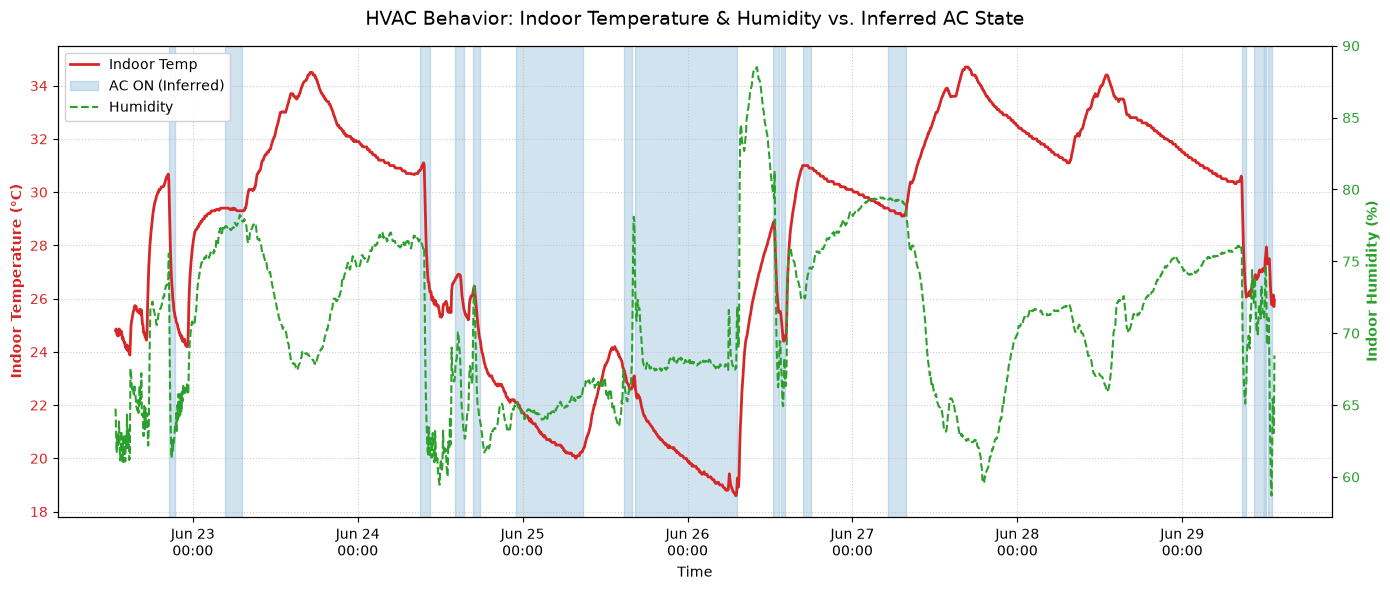

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure Datetime is the index for plotting
if 'Datetime' in df_final.columns:
    df_plot = df_final.set_index('Datetime')
else:
    df_plot = df_final.copy()

# Filter a 2-day window to make the chart readable
# (Plotting 7 full days on one chart squashes the lines too much)
# Adjust these dates based on the actual dates in your dataset
start_date = '2026-06-22 00:00:00'
end_date = '2026-06-29 23:59:59'
df_subset = df_plot.loc[start_date:end_date]

# Create the plot figure
fig, ax1 = plt.subplots(figsize=(14, 6))

# 1. Plot the Indoor Temperature
color1 = 'tab:red'
ax1.set_xlabel('Time')
ax1.set_ylabel('Indoor Temperature (°C)', color=color1, fontweight='bold')
ax1.plot(df_subset.index, df_subset['IndoorTemp'], color=color1, linewidth=2, label='Indoor Temp')
ax1.tick_params(axis='y', labelcolor=color1)

# 2. Plot the Indoor Humidity on a secondary Y-axis
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Indoor Humidity (%)', color=color2, fontweight='bold')
ax2.plot(df_subset.index, df_subset['IndoorHumidity'], color=color2, linewidth=1.5, linestyle='--', label='Humidity')
ax2.tick_params(axis='y', labelcolor=color2)

# 3. Highlight the background when the AC is ON (Predicted_AC = 1)
# This fills the background vertically wherever the AC_State column equals 1
ax1.fill_between(
    df_subset.index,
    0, 1,
    where=(df_subset['AC_State'] == 1),
    color='tab:blue',
    alpha=0.2,
    transform=ax1.get_xaxis_transform(),
    label='AC ON (Inferred)'
)

# 4. Formatting and aesthetics
plt.title('HVAC Behavior: Indoor Temperature & Humidity vs. Inferred AC State', fontsize=14, pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)

# Format the x-axis to show days and hours cleanly
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.xticks(rotation=0)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

# Assume df_final is your labeled 5-minute dataset
# Ensure Datetime is a column, not just the index
if 'Datetime' not in df_final.columns:
    df_final = df_final.reset_index()

# 1. Create a unique ID for every continuous block of AC states
# This increments the ID by 1 every time the AC switches from ON to OFF or OFF to ON
df_final['Cycle_ID'] = (df_final['AC_State'] != df_final['AC_State'].shift()).cumsum()

# 2. Filter to look ONLY at the periods where the AC was ON
on_cycles = df_final[df_final['AC_State'] == 1]

# 3. Group by the Cycle_ID to calculate the stats for each continuous run
diagnostics = on_cycles.groupby('Cycle_ID').agg(
    Start_Time=('Datetime', 'first'),
    End_Time=('Datetime', 'last'),
    Start_Temp=('IndoorTemp', 'first'),
    End_Temp=('IndoorTemp', 'last'),
    Avg_Outdoor_Temp=('OutdoorTemp', 'mean')
)

# 4. Calculate the duration in minutes
# We add 5 minutes because a single row represents a full 5-minute block of time
diagnostics['Duration_Minutes'] = (diagnostics['End_Time'] - diagnostics['Start_Time']).dt.seconds / 60 + 5

# 5. Calculate the Temperature Drop (The Deadband)
diagnostics['Temp_Drop'] = diagnostics['Start_Temp'] - diagnostics['End_Temp']

# Reorder columns for readability
diagnostics = diagnostics[['Start_Time', 'Duration_Minutes', 'Start_Temp', 'End_Temp', 'Temp_Drop', 'Avg_Outdoor_Temp']]

print("=== AC Cycle Diagnostics ===")
print(diagnostics.head(10))

print("\n=== Logical Sanity Checks ===")
print(f"Average Cycle Duration: {diagnostics['Duration_Minutes'].mean():.1f} minutes (Should be 15-45 mins)")
print(f"Average Turn-ON Temp:   {diagnostics['Start_Temp'].mean():.1f} °C")
print(f"Average Turn-OFF Temp:  {diagnostics['End_Temp'].mean():.1f} °C")
print(f"Average Deadband:       {diagnostics['Temp_Drop'].mean():.1f} °C (Should be 1.0 - 2.5 °C)")

=== AC Cycle Diagnostics ===
                  Start_Time  Duration_Minutes  Start_Temp  End_Temp  \
Cycle_ID                                                               
2        2026-06-22 20:30:00              60.0       30.44     25.30   
4        2026-06-23 04:45:00             150.0       29.40     29.30   
6        2026-06-24 09:00:00              95.0       30.80     26.26   
8        2026-06-24 14:05:00              85.0       26.68     25.66   
10       2026-06-24 16:50:00              65.0       26.34     24.44   
12       2026-06-24 23:00:00             595.0       22.10     20.36   
14       2026-06-25 14:45:00              75.0       23.30     22.64   
16       2026-06-25 16:20:00             900.0       22.90     19.26   
18       2026-06-26 12:30:00              50.0       28.86     25.48   
20       2026-06-26 13:40:00              40.0       25.16     24.50   

          Temp_Drop  Avg_Outdoor_Temp  
Cycle_ID                               
2              5.14       

In [7]:
df_final.head()

,index,Datetime,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed,DayName,Weekend,AC_State,Cycle_ID
0,0,2026-06-22 12:45:00,24.80,64.75,26.374583,91.381025,0.0,98.191667,3.885807,Monday,0,0,1
1,1,2026-06-22 12:50:00,24.86,63.02,26.336666,91.660136,0.0,98.133333,3.798822,Monday,0,0,1
2,2,2026-06-22 12:55:00,24.70,61.68,26.282500,92.058876,0.0,98.050000,3.674558,Monday,0,0,1
3,3,2026-06-22 13:00:00,24.62,62.90,26.238333,92.362474,0.0,97.766666,3.607138,Monday,0,0,1
4,4,2026-06-22 13:05:00,24.66,62.20,26.209167,92.523360,0.0,97.183333,3.624982,Monday,0,0,1


## Room Thermodynamic Modeling

Training Autoregressive XGBoost on Delta-T...
Starting Delta-T Free-Run Simulation for 80 steps...


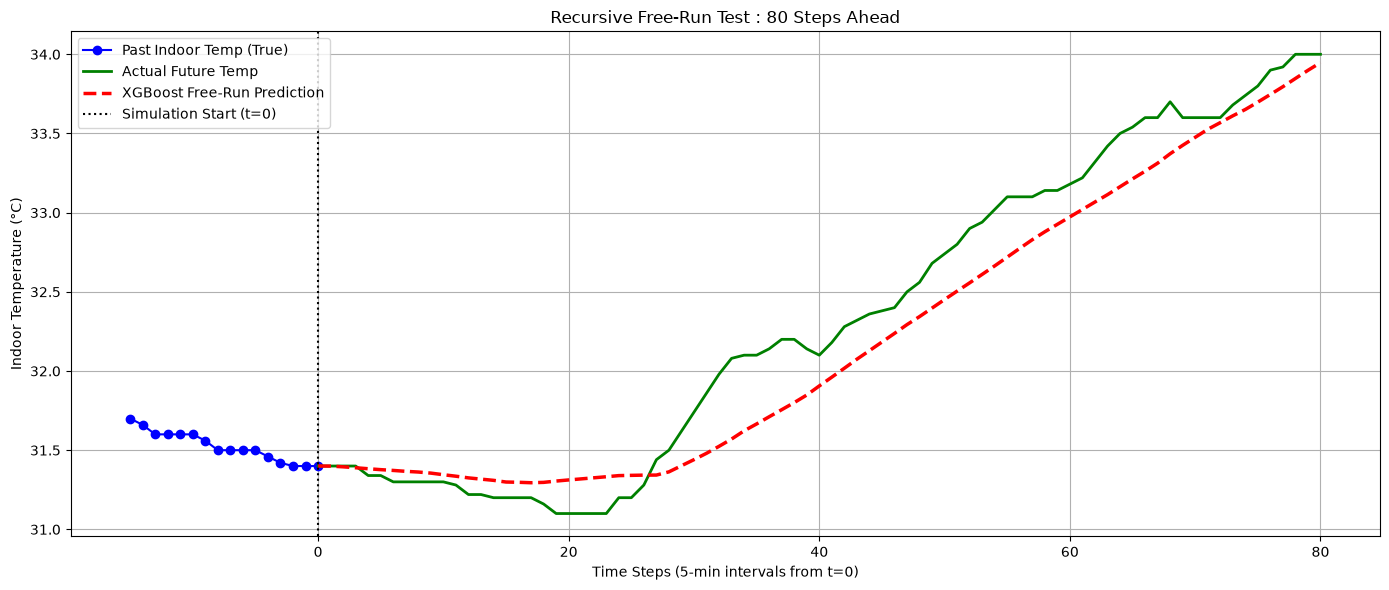

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# ==========================================
# 0. LOAD DATA
# ==========================================
# Use your actual real dataset
df = df_final.copy()

# Ensure Datetime is proper format and sorted chronologically
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# ==========================================
# 1. PREPARE DATA FOR DELTA PREDICTION
# ==========================================
# Cyclical Time Features
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)

# Thermodynamic drivers
df['Temp_Diff'] = df['OutdoorTemp'] - df['IndoorTemp']

# Lags & Momentum
df['IndoorTemp_Lag1'] = df['IndoorTemp'].shift(1)
df['Temp_Change_Rate'] = df['IndoorTemp'] - df['IndoorTemp_Lag1']
df['AC_State_Lag1'] = df['AC_State'].shift(1)

# 1. Short-term memory (What happened over the last hour?)
df['IndoorTemp_RollingMean_1hr'] = df['IndoorTemp'].rolling(window=12).mean()

# 2. Thermal Mass memory (How much heat soaked into the walls over the last 4 hours?)
df['OutdoorTemp_RollingMean_4hr'] = df['OutdoorTemp'].rolling(window=48).mean()

# 3. Deep Lags (What was the exact temperature exactly 1 hour ago?)
df['IndoorTemp_Lag12'] = df['IndoorTemp'].shift(12)

# THE CRITICAL FIX: The target is now the CHANGE in temperature (Delta-T)
df['Target_Delta_Next_Step'] = df['IndoorTemp'].shift(-1) - df['IndoorTemp']

# Drop NaNs caused by the shifting operations
df = df.dropna().reset_index(drop=True)

# FIX #1: Removed 'Target_Delta_Next_Step' from this list! It belongs only in 'y'
features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity',
    'Rain', 'CloudCover', 'WindSpeed', 'Temp_Diff', 'AC_State',
    'Hour_sin', 'Hour_cos', 'IndoorTemp_Lag1', 'Temp_Change_Rate', 'AC_State_Lag1',
    'IndoorTemp_RollingMean_1hr', 'OutdoorTemp_RollingMean_4hr', 'IndoorTemp_Lag12'
]

X = df[features].values
y = df['Target_Delta_Next_Step'].values # Training on Delta-T!

# Chronological Train/Test Split (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
df_test = df.iloc[split:].reset_index(drop=True)


# ==========================================
# 2. TRAIN AUTOREGRESSIVE XGBOOST
# ==========================================
print("Training Autoregressive XGBoost on Delta-T...")
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)
model.fit(X_train, y_train)

# ==========================================
# 3. RECURSIVE FREE-RUN SIMULATION (DELTA MODE)
# ==========================================
HORIZON = 80
past_context = 15

start_idx = past_context
for i in range(past_context, len(df_test) - HORIZON - 1):
    if df_test['AC_State'].iloc[i+1] == 1 and df_test['AC_State'].iloc[i] == 0:
        start_idx = i
        break

# Initialize simulation variables
current_simulated_temp = df_test['IndoorTemp'].iloc[start_idx]
current_lag1_temp = df_test['IndoorTemp_Lag1'].iloc[start_idx]
current_ac_lag1 = df_test['AC_State_Lag1'].iloc[start_idx]
constant_indoor_h = df_test['IndoorHumidity'].iloc[start_idx]

# FIX #2: We need a "Memory Buffer" of the last 12 temperatures to calculate rolling features
# We initialize it with the true past 12 steps leading up to t=0
simulated_temp_history = list(df_test['IndoorTemp'].iloc[start_idx - 11 : start_idx + 1].values)

predictions = []
actuals = df_test['IndoorTemp'].iloc[start_idx + 1 : start_idx + 1 + HORIZON].values

print(f"Starting Delta-T Free-Run Simulation for {HORIZON} steps...")

for step in range(HORIZON):
    current_idx = start_idx + step + 1

    # "Future Knowns" (Weather & AC Schedule)
    outdoor_t = df_test['OutdoorTemp'].iloc[current_idx]
    outdoor_h = df_test['OutdoorHumidity'].iloc[current_idx]
    rain = df_test['Rain'].iloc[current_idx]
    clouds = df_test['CloudCover'].iloc[current_idx]
    wind = df_test['WindSpeed'].iloc[current_idx]
    ac = df_test['AC_State'].iloc[current_idx]
    hr_sin = df_test['Hour_sin'].iloc[current_idx]
    hr_cos = df_test['Hour_cos'].iloc[current_idx]

    # We can just read the Outdoor rolling mean from the test dataset because it is future weather!
    outdoor_t_rolling_4hr = df_test['OutdoorTemp_RollingMean_4hr'].iloc[current_idx]

    # Dynamic simulated features
    temp_diff = outdoor_t - current_simulated_temp
    temp_change_rate = current_simulated_temp - current_lag1_temp

    # FIX #2 continued: Dynamically calculate Indoor Rolling Mean and Lag12 using our memory buffer
    indoor_t_rolling_1hr = np.mean(simulated_temp_history[-12:]) # Average of the last 12 predictions
    indoor_t_lag12 = simulated_temp_history[-12]                 # The prediction from exactly 12 steps ago

    # Build feature vector (Now perfectly matching the 17 features)
    X_step = np.array([[
        current_simulated_temp, constant_indoor_h, outdoor_t, outdoor_h,
        rain, clouds, wind, temp_diff, ac,
        hr_sin, hr_cos, current_lag1_temp, temp_change_rate, current_ac_lag1,
        indoor_t_rolling_1hr, outdoor_t_rolling_4hr, indoor_t_lag12
    ]])

    # Predict DELTA
    predicted_delta = model.predict(X_step)[0]
    next_temp = current_simulated_temp + predicted_delta
    predictions.append(next_temp)

    # UPDATE VARIABLES & BUFFER FOR THE NEXT LOOP
    current_lag1_temp = current_simulated_temp
    current_ac_lag1 = ac
    current_simulated_temp = next_temp
    simulated_temp_history.append(next_temp) # Add newest prediction to memory buffer


# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 6))

past_actuals = df_test['IndoorTemp'].iloc[start_idx - past_context : start_idx + 1].values
time_past = range(-past_context, 1)
plt.plot(time_past, past_actuals, label='Past Indoor Temp (True)', color='blue', marker='o')

time_future = range(1, HORIZON + 1)
time_pred = [0] + list(time_future)
actual_line = [past_actuals[-1]] + list(actuals)
pred_line = [past_actuals[-1]] + list(predictions)

plt.plot(time_pred, actual_line, label='Actual Future Temp', color='green', linewidth=2)
plt.plot(time_pred, pred_line, label='XGBoost Free-Run Prediction', color='red', linestyle='--', linewidth=2.5)

for t, ac_is_on in zip(time_future, df_test['AC_State'].iloc[start_idx + 1 : start_idx + 1 + HORIZON]):
    if ac_is_on == 1:
        plt.axvspan(t-0.5, t+0.5, color='cyan', alpha=0.15, lw=0)

plt.axvline(x=0, color='black', linestyle=':', label='Simulation Start (t=0)')
plt.title(f"Recursive Free-Run Test : {HORIZON} Steps Ahead")
plt.xlabel("Time Steps (5-min intervals from t=0)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Preparing dataset and engineering features...

--- PHASE 1: PHYSICS VERIFICATION ---
Training Environment Digital Twin (XGBoost Regressor)...
Running Free-Run Test to verify thermodynamics on unseen data...


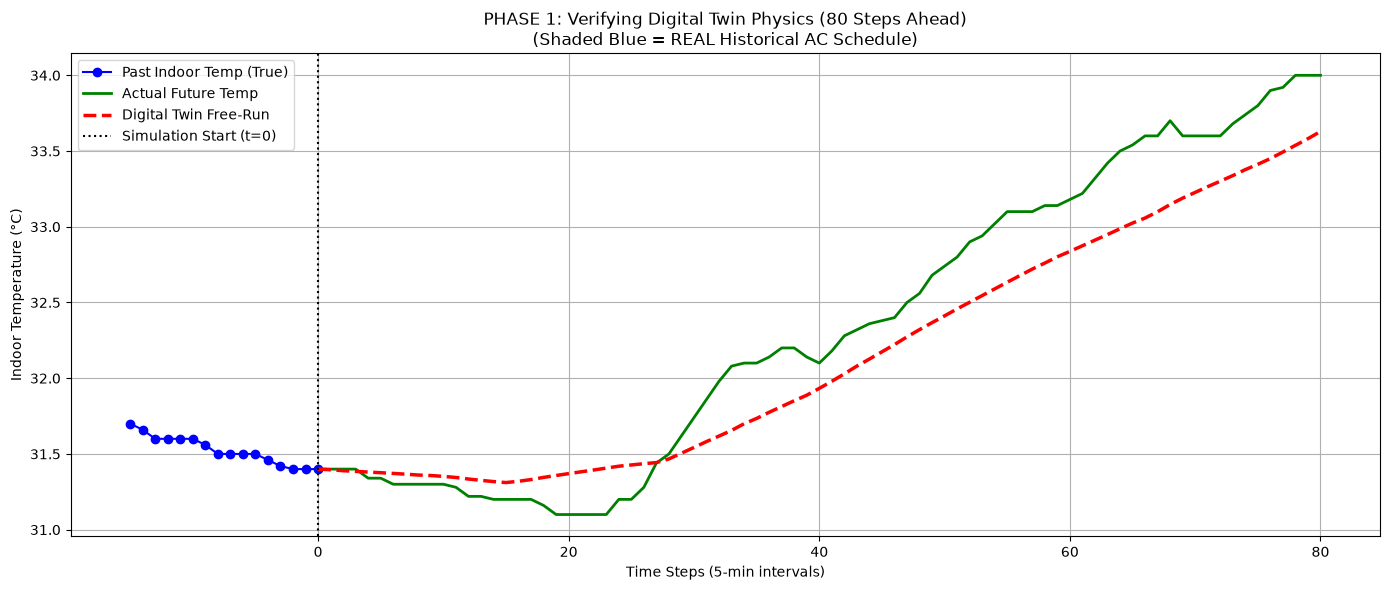


--- PHASE 2: AUTONOMOUS OPTIMIZATION ---
Running MPC Teacher to generate optimal AC actions (generating training data)...


100%|██████████| 1558/1558 [04:49<00:00,  5.39it/s]



Training the Agent Optimizer (XGBoost Classifier)...
Running Autonomous Control Simulation on Testing Dataset...


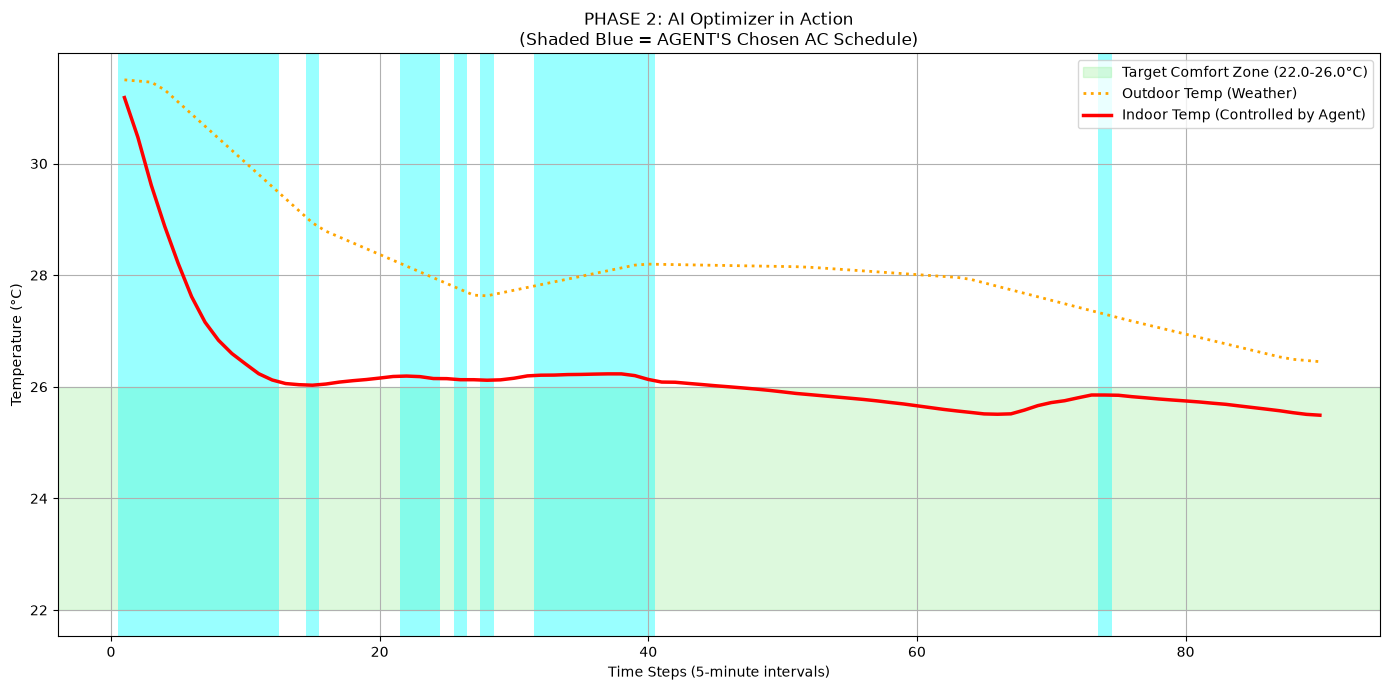


=== Autonomous Controller Performance ===
Time spent inside Comfort Zone: 45/90 steps (50.0%)
Energy Used (Steps AC was ON):  28/90 steps


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import itertools
from tqdm import tqdm

# ==========================================
# 0. LOAD AND PREPARE THE DATASET
# ==========================================
print("Preparing dataset and engineering features...")
df = df_final.copy()
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Time & Basic Physics
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Temp_Diff'] = df['OutdoorTemp'] - df['IndoorTemp']

# Short Lags
df['IndoorTemp_Lag1'] = df['IndoorTemp'].shift(1)
df['Temp_Change_Rate'] = df['IndoorTemp'] - df['IndoorTemp_Lag1']
df['AC_State_Lag1'] = df['AC_State'].shift(1)

# Deep Memory (Thermal Mass)
df['IndoorTemp_RollingMean_1hr'] = df['IndoorTemp'].rolling(window=12).mean()
df['OutdoorTemp_RollingMean_4hr'] = df['OutdoorTemp'].rolling(window=48).mean()
df['IndoorTemp_Lag12'] = df['IndoorTemp'].shift(12)

# THE TARGET: Predicting Delta-T
df['Target_Delta_Next_Step'] = df['IndoorTemp'].shift(-1) - df['IndoorTemp']

df = df.dropna().reset_index(drop=True)

# Environment Model Features (17 Features)
env_features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity', 
    'Rain', 'CloudCover', 'WindSpeed', 'Temp_Diff', 'AC_State', 
    'Hour_sin', 'Hour_cos', 'IndoorTemp_Lag1', 'Temp_Change_Rate', 'AC_State_Lag1',
    'IndoorTemp_RollingMean_1hr', 'OutdoorTemp_RollingMean_4hr', 'IndoorTemp_Lag12'
]

X = df[env_features].values
y = df['Target_Delta_Next_Step'].values 

# STRICT SPLIT: 80% Train, 20% Test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

df_train = df.iloc[:split].reset_index(drop=True)
df_test = df.iloc[split:].reset_index(drop=True)


# ==========================================
# 1. TRAIN THE ENVIRONMENT DIGITAL TWIN 
# ==========================================
print("\n--- PHASE 1: PHYSICS VERIFICATION ---")
print("Training Environment Digital Twin (XGBoost Regressor)...")
env_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.03, 
    subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror'
)

# Fix the Data Imbalance (Give AC ON data 3x weight)
ac_col_index = env_features.index('AC_State')
ac_states_train = X_train[:, ac_col_index]
sample_weights = np.where(ac_states_train == 1, 3.0, 1.0) 

env_model.fit(X_train, y_train, sample_weight=sample_weights)


# ==========================================
# 2. VERIFY THE DIGITAL TWIN (HISTORICAL FREE-RUN)
# ==========================================
print("Running Free-Run Test to verify thermodynamics on unseen data...")
DT_HORIZON = 80       
past_context = 15  

# Find a spot in the Test set where the real AC turns ON to test the cooling physics
dt_start_idx = past_context 
for i in range(past_context, len(df_test) - DT_HORIZON - 1):
    if df_test['AC_State'].iloc[i+1] == 1 and df_test['AC_State'].iloc[i] == 0:
        dt_start_idx = i
        break

dt_current_temp = df_test['IndoorTemp'].iloc[dt_start_idx]
dt_current_lag1 = df_test['IndoorTemp_Lag1'].iloc[dt_start_idx]
dt_current_ac_lag1 = df_test['AC_State_Lag1'].iloc[dt_start_idx]
dt_constant_h = df_test['IndoorHumidity'].iloc[dt_start_idx] 
dt_sim_history = list(df_test['IndoorTemp'].iloc[dt_start_idx - 11 : dt_start_idx + 1].values)

dt_predictions = []
dt_actuals = df_test['IndoorTemp'].iloc[dt_start_idx + 1 : dt_start_idx + 1 + DT_HORIZON].values

for step in range(DT_HORIZON):
    idx = dt_start_idx + step + 1 
    
    # Future Knowns (Using the REAL historical AC schedule)
    out_t, out_h = df_test['OutdoorTemp'].iloc[idx], df_test['OutdoorHumidity'].iloc[idx]
    rain, clouds, wind = df_test['Rain'].iloc[idx], df_test['CloudCover'].iloc[idx], df_test['WindSpeed'].iloc[idx]
    ac = df_test['AC_State'].iloc[idx]
    hr_sin, hr_cos = df_test['Hour_sin'].iloc[idx], df_test['Hour_cos'].iloc[idx]
    out_t_roll = df_test['OutdoorTemp_RollingMean_4hr'].iloc[idx]
    
    t_diff = out_t - dt_current_temp
    t_change = dt_current_temp - dt_current_lag1
    in_t_roll = np.mean(dt_sim_history[-12:]) 
    in_t_lag12 = dt_sim_history[-12]                 
    
    X_step = np.array([[
        dt_current_temp, dt_constant_h, out_t, out_h, rain, clouds, wind, t_diff, ac, 
        hr_sin, hr_cos, dt_current_lag1, t_change, dt_current_ac_lag1, in_t_roll, out_t_roll, in_t_lag12
    ]])
    
    next_temp = dt_current_temp + env_model.predict(X_step)[0]
    dt_predictions.append(next_temp)
    
    dt_current_lag1 = dt_current_temp
    dt_current_ac_lag1 = ac
    dt_current_temp = next_temp
    dt_sim_history.append(next_temp) 

# --- PLOT 1: Digital Twin Verification ---
plt.figure(figsize=(14, 6))
past_actuals = df_test['IndoorTemp'].iloc[dt_start_idx - past_context : dt_start_idx + 1].values
time_past = range(-past_context, 1)
time_future = range(1, DT_HORIZON + 1)

plt.plot(time_past, past_actuals, label='Past Indoor Temp (True)', color='blue', marker='o')
plt.plot([0] + list(time_future), [past_actuals[-1]] + list(dt_actuals), label='Actual Future Temp', color='green', linewidth=2)
plt.plot([0] + list(time_future), [past_actuals[-1]] + list(dt_predictions), label='Digital Twin Free-Run', color='red', linestyle='--', linewidth=2.5)

for t, ac_is_on in zip(time_future, df_test['AC_State'].iloc[dt_start_idx + 1 : dt_start_idx + 1 + DT_HORIZON]):
    if ac_is_on == 1:
        plt.axvspan(t-0.5, t+0.5, color='cyan', alpha=0.15, lw=0)

plt.axvline(x=0, color='black', linestyle=':', label='Simulation Start (t=0)')
plt.title(f"PHASE 1: Verifying Digital Twin Physics ({DT_HORIZON} Steps Ahead)\n(Shaded Blue = REAL Historical AC Schedule)")
plt.xlabel("Time Steps (5-min intervals)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================================
# 3. THE TEACHER: MPC DATASET GENERATOR
# ==========================================
print("\n--- PHASE 2: AUTONOMOUS OPTIMIZATION ---")
print("Running MPC Teacher to generate optimal AC actions (generating training data)...")
COMFORT_MIN = 22.0  
COMFORT_MAX = 26.0  

def calculate_cost(predicted_temps, ac_schedule):
    cost = 0.0
    for temp, ac in zip(predicted_temps, ac_schedule):
        if ac == 1: cost += 1.0 # Energy Penalty
        if temp > COMFORT_MAX: cost += (temp - COMFORT_MAX) * 30.0 # Hot Penalty
        elif temp < COMFORT_MIN: cost += (COMFORT_MIN - temp) * 15.0 # Cold Penalty
    return cost

MPC_HORIZON = 7 
all_possible_schedules = list(itertools.product([0, 1], repeat=MPC_HORIZON))

optimizer_X, optimizer_y = [], []
start_gen_idx = 15
end_gen_idx = min(3000, len(df_train) - MPC_HORIZON - 1) 

for i in tqdm(range(start_gen_idx, end_gen_idx)):
    best_cost = float('inf')
    best_action = 0
    
    current_temp = df_train['IndoorTemp'].iloc[i]
    current_lag1 = df_train['IndoorTemp_Lag1'].iloc[i]
    current_ac_lag1 = df_train['AC_State_Lag1'].iloc[i]
    constant_h = df_train['IndoorHumidity'].iloc[i]
    temp_history = list(df_train['IndoorTemp'].iloc[i - 11 : i + 1].values)
    
    for schedule in all_possible_schedules:
        sim_temp, sim_lag1, sim_ac_lag1, sim_history = current_temp, current_lag1, current_ac_lag1, temp_history.copy()
        pred_temps = []
        
        for step in range(MPC_HORIZON):
            idx = i + step + 1
            ac = schedule[step]
            
            out_t, out_h = df_train['OutdoorTemp'].iloc[idx], df_train['OutdoorHumidity'].iloc[idx]
            rain, clouds, wind = df_train['Rain'].iloc[idx], df_train['CloudCover'].iloc[idx], df_train['WindSpeed'].iloc[idx]
            hr_sin, hr_cos = df_train['Hour_sin'].iloc[idx], df_train['Hour_cos'].iloc[idx]
            out_t_roll = df_train['OutdoorTemp_RollingMean_4hr'].iloc[idx]
            
            t_diff = out_t - sim_temp
            t_change = sim_temp - sim_lag1
            in_t_roll = np.mean(sim_history[-12:])
            in_t_lag12 = sim_history[-12]
            
            X_step = np.array([[
                sim_temp, constant_h, out_t, out_h, rain, clouds, wind, t_diff, ac,
                hr_sin, hr_cos, sim_lag1, t_change, sim_ac_lag1, in_t_roll, out_t_roll, in_t_lag12
            ]])
            
            sim_temp += env_model.predict(X_step)[0]
            pred_temps.append(sim_temp)
            sim_lag1, sim_ac_lag1 = sim_temp, ac
            sim_history.append(sim_temp)
            
        cost = calculate_cost(pred_temps, schedule)
        if cost < best_cost:
            best_cost = cost
            best_action = schedule[0]
            
    state_features = [
        df_train['IndoorTemp'].iloc[i], df_train['IndoorHumidity'].iloc[i], df_train['OutdoorTemp'].iloc[i], df_train['OutdoorHumidity'].iloc[i], 
        df_train['Rain'].iloc[i], df_train['CloudCover'].iloc[i], df_train['WindSpeed'].iloc[i], df_train['OutdoorTemp'].iloc[i] - df_train['IndoorTemp'].iloc[i], 
        df_train['Hour_sin'].iloc[i], df_train['Hour_cos'].iloc[i], df_train['IndoorTemp_Lag1'].iloc[i], df_train['IndoorTemp'].iloc[i] - df_train['IndoorTemp_Lag1'].iloc[i], 
        df_train['AC_State_Lag1'].iloc[i], df_train['IndoorTemp_RollingMean_1hr'].iloc[i], df_train['OutdoorTemp_RollingMean_4hr'].iloc[i], df_train['IndoorTemp_Lag12'].iloc[i]
    ]
    optimizer_X.append(state_features)
    optimizer_y.append(best_action)


# ==========================================
# 4. TRAIN THE AGENT
# ==========================================
print("\nTraining the Agent Optimizer (XGBoost Classifier)...")
agent_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, eval_metric='logloss')
agent_model.fit(np.array(optimizer_X), np.array(optimizer_y))


# ==========================================
# 5. FINAL TEST: AUTONOMOUS CONTROL
# ==========================================
print("Running Autonomous Control Simulation on Testing Dataset...")
AGENT_HORIZON = 90 
test_start_idx = dt_start_idx # Use the exact same starting point as Phase 1 for a fair comparison!

ag_current_temp = df_test['IndoorTemp'].iloc[test_start_idx]
ag_current_lag1 = df_test['IndoorTemp_Lag1'].iloc[test_start_idx]
ag_current_ac_lag1 = df_test['AC_State_Lag1'].iloc[test_start_idx]
ag_constant_h = df_test['IndoorHumidity'].iloc[test_start_idx]
ag_sim_history = list(df_test['IndoorTemp'].iloc[test_start_idx - 11 : test_start_idx + 1].values)

agent_predictions = []
agent_actions = []

for step in range(AGENT_HORIZON):
    idx = test_start_idx + step + 1
    
    out_t, out_h = df_test['OutdoorTemp'].iloc[idx], df_test['OutdoorHumidity'].iloc[idx]
    rain, clouds, wind = df_test['Rain'].iloc[idx], df_test['CloudCover'].iloc[idx], df_test['WindSpeed'].iloc[idx]
    hr_sin, hr_cos = df_test['Hour_sin'].iloc[idx], df_test['Hour_cos'].iloc[idx]
    out_t_roll = df_test['OutdoorTemp_RollingMean_4hr'].iloc[idx]
    
    t_diff = out_t - ag_current_temp
    t_change = ag_current_temp - ag_current_lag1
    in_t_roll = np.mean(ag_sim_history[-12:])
    in_t_lag12 = ag_sim_history[-12]
    
    # AGENT CHOOSES ACTION
    agent_features = np.array([[
        ag_current_temp, ag_constant_h, out_t, out_h, rain, clouds, wind, t_diff,
        hr_sin, hr_cos, ag_current_lag1, t_change, ag_current_ac_lag1, in_t_roll, out_t_roll, in_t_lag12
    ]])
    chosen_ac_state = agent_model.predict(agent_features)[0]
    agent_actions.append(chosen_ac_state)
    
    # DIGITAL TWIN EXECUTES ACTION
    env_features = np.array([[
        ag_current_temp, ag_constant_h, out_t, out_h, rain, clouds, wind, t_diff, chosen_ac_state, 
        hr_sin, hr_cos, ag_current_lag1, t_change, ag_current_ac_lag1, in_t_roll, out_t_roll, in_t_lag12
    ]])
    next_temp = ag_current_temp + env_model.predict(env_features)[0]
    agent_predictions.append(next_temp)
    
    ag_current_lag1 = ag_current_temp
    ag_current_ac_lag1 = chosen_ac_state
    ag_current_temp = next_temp
    ag_sim_history.append(next_temp)

# --- PLOT 2: Autonomous Agent Control ---
plt.figure(figsize=(14, 7))
time_steps = range(1, AGENT_HORIZON + 1)
outdoor_actuals = df_test['OutdoorTemp'].iloc[test_start_idx + 1 : test_start_idx + 1 + AGENT_HORIZON].values

plt.axhspan(COMFORT_MIN, COMFORT_MAX, color='lightgreen', alpha=0.3, label=f'Target Comfort Zone ({COMFORT_MIN}-{COMFORT_MAX}°C)')
plt.plot(time_steps, outdoor_actuals, label='Outdoor Temp (Weather)', color='orange', linestyle=':', linewidth=2)
plt.plot(time_steps, agent_predictions, label='Indoor Temp (Controlled by Agent)', color='red', linewidth=2.5)

for t, ac in zip(time_steps, agent_actions):
    if ac == 1:
        plt.axvspan(t-0.5, t+0.5, color='cyan', alpha=0.4, lw=0)

plt.title("PHASE 2: AI Optimizer in Action\n(Shaded Blue = AGENT'S Chosen AC Schedule)")
plt.xlabel("Time Steps (5-minute intervals)")
plt.ylabel("Temperature (°C)")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Performance Metrics
time_in_bounds = sum(1 for t in agent_predictions if COMFORT_MIN <= t <= COMFORT_MAX)
print(f"\n=== Autonomous Controller Performance ===")
print(f"Time spent inside Comfort Zone: {time_in_bounds}/{AGENT_HORIZON} steps ({(time_in_bounds/AGENT_HORIZON)*100:.1f}%)")
print(f"Energy Used (Steps AC was ON):  {sum(agent_actions)}/{AGENT_HORIZON} steps")

Occupied days found in test dataset: ['2026-06-28']


,Metric,Baseline,AI Agent Optimized,Savings,Savings %
0,AC Runtime (hours),12.00,1.50,10.50,87.5
1,Energy Consumption (kWh),33.60,4.20,29.40,87.5
2,Electricity Cost (RM),15.25,1.91,13.35,87.5
3,CO2 Emissions (kg),26.01,3.25,22.76,87.5



Comfort check: Agent max temp 31.34 degC vs ceiling 26.0 degC
Relatable equivalents: 1.1 tree-years of CO2 absorption, 190 km not driven
Peak-hour (14:00-17:00) runtime reduction: 100.0%

Projected over a year (extrapolated from observed test days):
  - Cost saved  : RM 9743.75
  - CO2 avoided : 16.612 tonnes


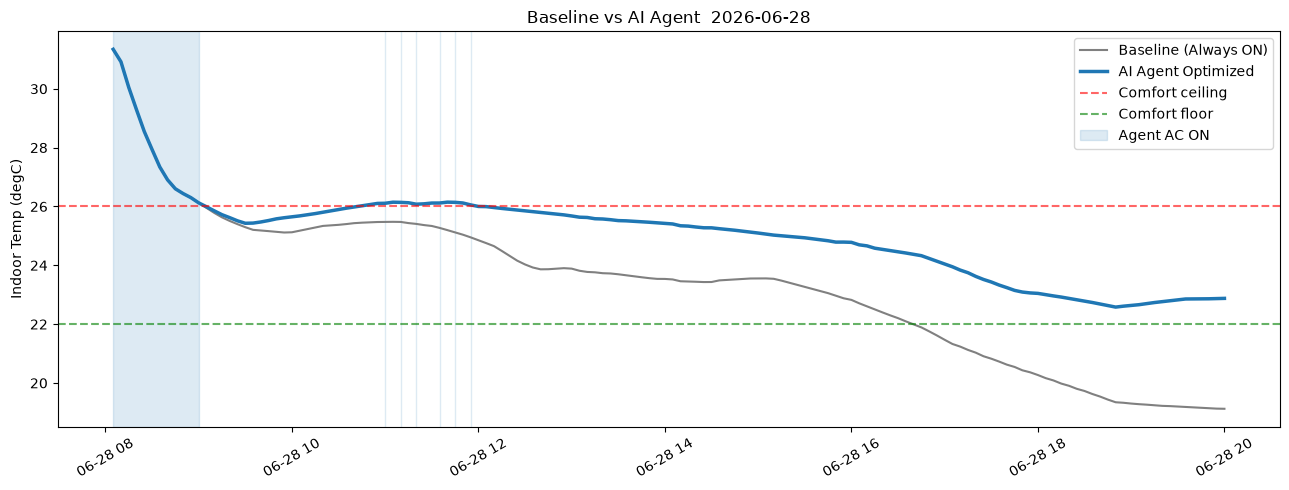

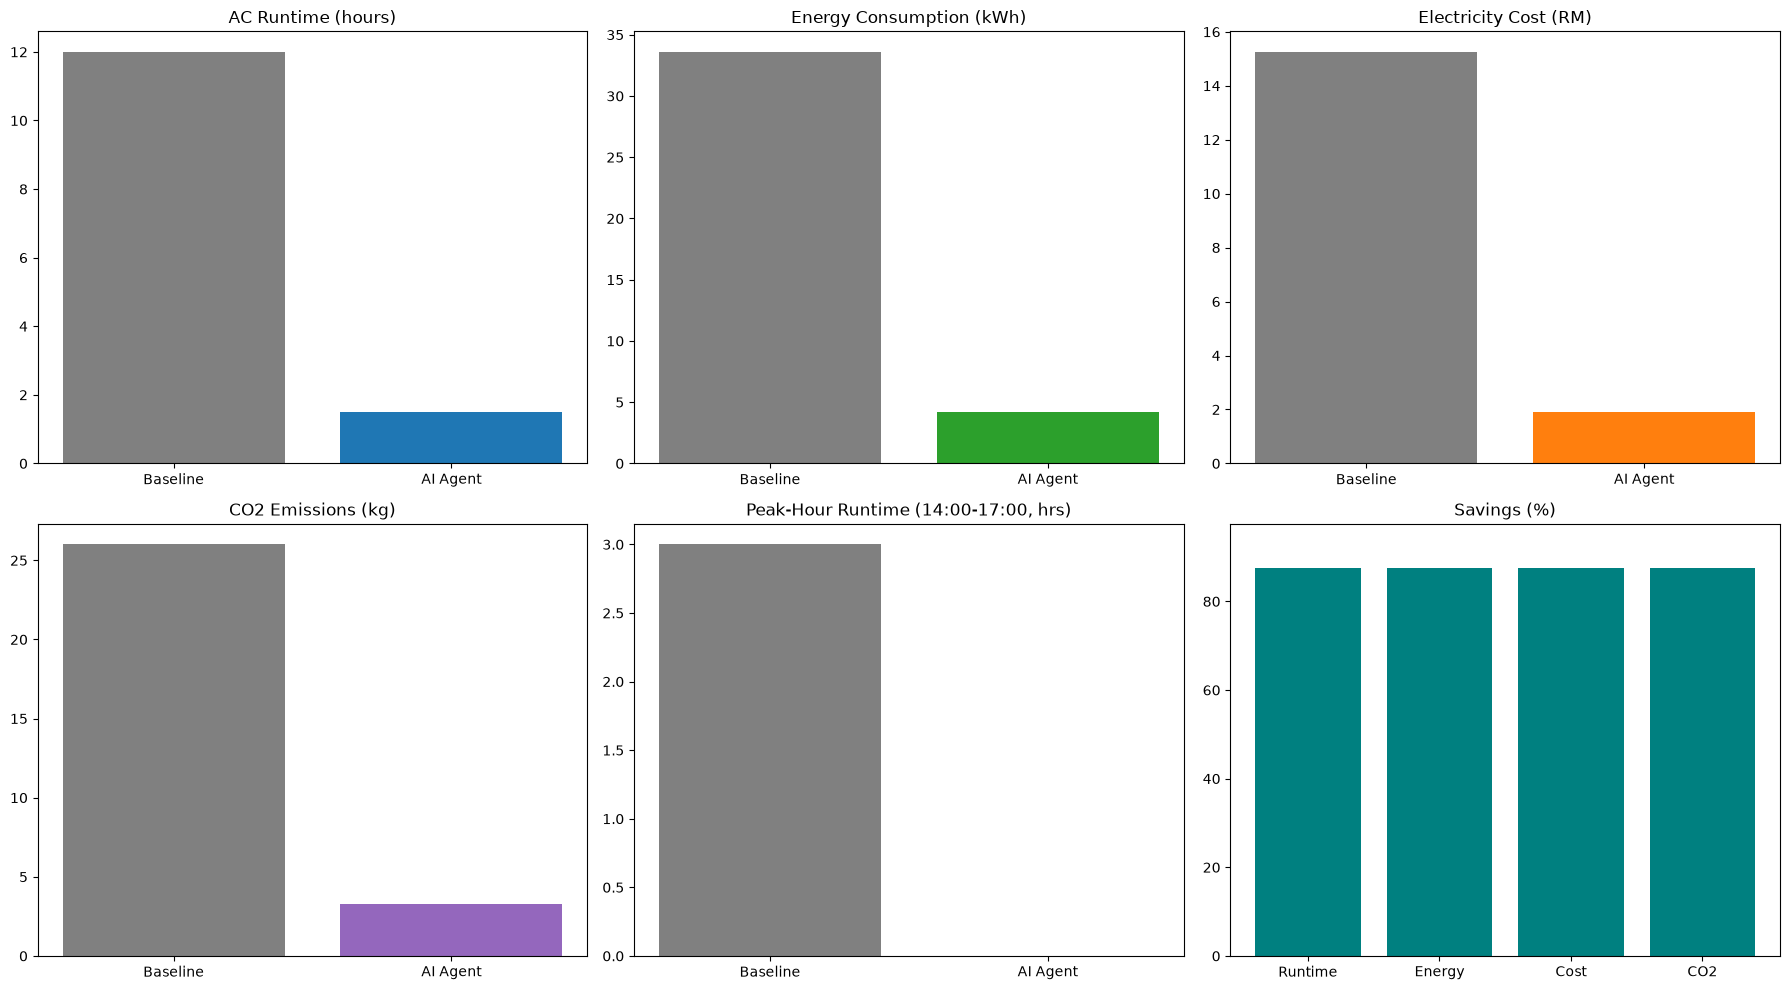

In [18]:
# ==========================================
# PART 1: CONSTANTS & PREPARATION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Business & Physics Constants (From Teammate)
AC_POWER_KW = 2.8
TARIFF_RM_PER_KWH = 0.454
SAMPLE_MINUTES = 5

GRID_EMISSION_FACTOR = 0.774     # kg CO2e per kWh (TNB grid factor)
TREE_ABSORPTION_KG_YR = 21
CAR_EMISSION_KG_KM = 0.12
PEAK_HOUR_START, PEAK_HOUR_END = 14, 17

# Occupancy Calendar
NO_CLASS_DAYS = ["Tuesday", "Thursday"]
OCCUPIED_HOUR_START, OCCUPIED_HOUR_END = 8, 20
COMFORT_MAX_C = 26.0
COMFORT_MIN_C = 22.0 # Using the realistic bounds we set for the agent

# Ensure df_test has Hour and DayName for the calendar filtering
df_test['Hour'] = df_test['Datetime'].dt.hour
df_test['DayName'] = df_test['Datetime'].dt.day_name()

# ==========================================
# PART 2: OCCUPIED WINDOW EXTRACTOR
# ==========================================
def get_occupied_day_windows(df, no_class_days, hour_start, hour_end):
    windows = []
    steps_per_window = (hour_end - hour_start) * (60 // SAMPLE_MINUTES)
    for d in sorted(df["Datetime"].dt.date.unique()):
        day_name = df.loc[df["Datetime"].dt.date == d, "DayName"].iloc[0]
        if day_name in no_class_days:
            continue # Skip Tuesdays and Thursdays
        
        match = df.index[(df["Datetime"].dt.date == d) & (df["Hour"] == hour_start)]
        if len(match) == 0:
            continue
            
        start_idx = match[0]
        if start_idx < 12 or start_idx + steps_per_window >= len(df):
            continue  # Ensure we have enough history and future data
            
        windows.append((d, start_idx, steps_per_window))
    return windows

day_windows = get_occupied_day_windows(df_test, NO_CLASS_DAYS, OCCUPIED_HOUR_START, OCCUPIED_HOUR_END)
print(f"Occupied days found in test dataset: {[str(d) for d, _, _ in day_windows]}")


# ==========================================
# PART 3: DUAL-TRACK SIMULATION
# ==========================================
def simulate_agent_vs_baseline(env_model, agent_model, df, start_idx, horizon):
    """Simulates both Baseline (Always ON) and Agent policies in parallel."""
    
    # Track 1: Baseline States
    t_base = df["IndoorTemp"].iloc[start_idx]
    lag1_base = df["IndoorTemp_Lag1"].iloc[start_idx]
    ac_lag1_base = df["AC_State_Lag1"].iloc[start_idx]
    hist_base = list(df["IndoorTemp"].iloc[start_idx - 11: start_idx + 1].values)

    # Track 2: Agent States (Starts identical, but will diverge)
    t_opt = df["IndoorTemp"].iloc[start_idx]
    lag1_opt = df["IndoorTemp_Lag1"].iloc[start_idx]
    ac_lag1_opt = df["AC_State_Lag1"].iloc[start_idx]
    hist_opt = list(df["IndoorTemp"].iloc[start_idx - 11: start_idx + 1].values)

    constant_h = df["IndoorHumidity"].iloc[start_idx]
    res = []

    for step in range(horizon):
        idx = start_idx + step + 1
        if idx >= len(df): break

        # Shared Weather
        out_t, out_h = df["OutdoorTemp"].iloc[idx], df["OutdoorHumidity"].iloc[idx]
        rain, clouds, wind = df["Rain"].iloc[idx], df["CloudCover"].iloc[idx], df["WindSpeed"].iloc[idx]
        hr_sin, hr_cos = df["Hour_sin"].iloc[idx], df["Hour_cos"].iloc[idx]
        out_t_roll = df["OutdoorTemp_RollingMean_4hr"].iloc[idx]

        # -------------------------------------
        # TRACK 1: BASELINE (Always ON)
        # -------------------------------------
        ac_base = 1
        t_diff_base = out_t - t_base
        t_change_base = t_base - lag1_base
        
        X_base = np.array([[
            t_base, constant_h, out_t, out_h, rain, clouds, wind, t_diff_base, ac_base,
            hr_sin, hr_cos, lag1_base, t_change_base, ac_lag1_base, np.mean(hist_base[-12:]), out_t_roll, hist_base[-12]
        ]])
        t_base_next = t_base + env_model.predict(X_base)[0]

        # -------------------------------------
        # TRACK 2: AI AGENT
        # -------------------------------------
        t_diff_opt = out_t - t_opt
        t_change_opt = t_opt - lag1_opt
        
        # Ask Agent for decision
        X_agent = np.array([[
            t_opt, constant_h, out_t, out_h, rain, clouds, wind, t_diff_opt,
            hr_sin, hr_cos, lag1_opt, t_change_opt, ac_lag1_opt, np.mean(hist_opt[-12:]), out_t_roll, hist_opt[-12]
        ]])
        ac_opt = int(agent_model.predict(X_agent)[0])

        # Simulate Agent decision
        X_opt = np.array([[
            t_opt, constant_h, out_t, out_h, rain, clouds, wind, t_diff_opt, ac_opt,
            hr_sin, hr_cos, lag1_opt, t_change_opt, ac_lag1_opt, np.mean(hist_opt[-12:]), out_t_roll, hist_opt[-12]
        ]])
        t_opt_next = t_opt + env_model.predict(X_opt)[0]

        # -------------------------------------
        # Save and Update
        # -------------------------------------
        res.append({
            "Date": df["Datetime"].dt.date.iloc[idx],
            "Datetime": df["Datetime"].iloc[idx],
            "Hour": df["Hour"].iloc[idx],
            "Baseline_Temp": t_base_next, "Baseline_AC": ac_base,
            "Optimized_Temp": t_opt_next, "Optimized_AC": ac_opt,
        })

        # Update states for next step
        lag1_base, ac_lag1_base, t_base = t_base, ac_base, t_base_next
        hist_base.append(t_base_next)
        
        lag1_opt, ac_lag1_opt, t_opt = t_opt, ac_opt, t_opt_next
        hist_opt.append(t_opt_next)

    return res

# Run the simulation for all available occupied days
sim_rows = []
for (d, start_idx, horizon) in day_windows:
    day_res = simulate_agent_vs_baseline(env_model, agent_model, df_test, start_idx, horizon)
    sim_rows.extend(day_res)

df_sim = pd.DataFrame(sim_rows)


# ==========================================
# PART 4: COST, IMPACT & CALCULATIONS
# ==========================================
baseline_runtime_hr = df_sim["Baseline_AC"].sum() * SAMPLE_MINUTES / 60
ai_runtime_hr = df_sim["Optimized_AC"].sum() * SAMPLE_MINUTES / 60
data_span_days = len(day_windows) * (OCCUPIED_HOUR_END - OCCUPIED_HOUR_START) / 24

# Energy, Cost, CO2
baseline_energy_kwh = baseline_runtime_hr * AC_POWER_KW
ai_energy_kwh = ai_runtime_hr * AC_POWER_KW
energy_saved_kwh = baseline_energy_kwh - ai_energy_kwh
energy_saving_pct = (energy_saved_kwh / baseline_energy_kwh) * 100 if baseline_energy_kwh else 0

baseline_cost = baseline_energy_kwh * TARIFF_RM_PER_KWH
ai_cost = ai_energy_kwh * TARIFF_RM_PER_KWH
cost_saved = baseline_cost - ai_cost

co2_avoided_kg = energy_saved_kwh * GRID_EMISSION_FACTOR
trees_equivalent = co2_avoided_kg / TREE_ABSORPTION_KG_YR
km_not_driven_equivalent = co2_avoided_kg / CAR_EMISSION_KG_KM

# Peak Hour
peak_mask = (df_sim["Hour"] >= PEAK_HOUR_START) & (df_sim["Hour"] < PEAK_HOUR_END)
baseline_peak_hr = df_sim.loc[peak_mask, "Baseline_AC"].sum() * SAMPLE_MINUTES / 60
ai_peak_hr = df_sim.loc[peak_mask, "Optimized_AC"].sum() * SAMPLE_MINUTES / 60
peak_reduction_pct = (1 - ai_peak_hr / baseline_peak_hr) * 100 if baseline_peak_hr > 0 else 0

# Yearly Extrapolation
yearly_factor = 365 / data_span_days if data_span_days > 0 else 0
projected_yearly_cost_saved = cost_saved * yearly_factor
projected_yearly_co2_avoided_tonnes = (co2_avoided_kg * yearly_factor) / 1000

# Text Summary
summary = pd.DataFrame({
    "Metric": ["AC Runtime (hours)", "Energy Consumption (kWh)", "Electricity Cost (RM)", "CO2 Emissions (kg)"],
    "Baseline": [round(baseline_runtime_hr, 2), round(baseline_energy_kwh, 2), round(baseline_cost, 2), round(baseline_energy_kwh * GRID_EMISSION_FACTOR, 2)],
    "AI Agent Optimized": [round(ai_runtime_hr, 2), round(ai_energy_kwh, 2), round(ai_cost, 2), round(ai_energy_kwh * GRID_EMISSION_FACTOR, 2)],
})
summary["Savings"] = [round(baseline_runtime_hr - ai_runtime_hr, 2), round(energy_saved_kwh, 2), round(cost_saved, 2), round(co2_avoided_kg, 2)]
summary["Savings %"] = [
    round((1 - ai_runtime_hr / baseline_runtime_hr) * 100, 1) if baseline_runtime_hr else 0,
    round(energy_saving_pct, 1),
    round((cost_saved / baseline_cost) * 100, 1) if baseline_cost else 0,
    round((co2_avoided_kg / (baseline_energy_kwh * GRID_EMISSION_FACTOR)) * 100, 1) if baseline_energy_kwh else 0,
]

display(summary)
print(f"\nComfort check: Agent max temp {df_sim['Optimized_Temp'].max():.2f} degC vs ceiling {COMFORT_MAX_C} degC")
print(f"Relatable equivalents: {trees_equivalent:.1f} tree-years of CO2 absorption, {km_not_driven_equivalent:.0f} km not driven")
print(f"Peak-hour ({PEAK_HOUR_START}:00-{PEAK_HOUR_END}:00) runtime reduction: {peak_reduction_pct:.1f}%")
print(f"\nProjected over a year (extrapolated from observed test days):")
print(f"  - Cost saved  : RM {projected_yearly_cost_saved:.2f}")
print(f"  - CO2 avoided : {projected_yearly_co2_avoided_tonnes:.3f} tonnes")


# ==========================================
# PART 5: VISUALIZATIONS
# ==========================================
# 1. Time-Series Comparison Plot (First available day)
if len(day_windows) > 0:
    example_date = day_windows[0][0]
    sub = df_sim[df_sim["Date"] == example_date]

    plt.figure(figsize=(13, 5))
    plt.plot(sub["Datetime"], sub["Baseline_Temp"], color="gray", label="Baseline (Always ON)")
    plt.plot(sub["Datetime"], sub["Optimized_Temp"], color="tab:blue", linewidth=2.5, label="AI Agent Optimized")
    
    plt.axhline(COMFORT_MAX_C, color="red", linestyle="--", alpha=0.6, label="Comfort ceiling")
    plt.axhline(COMFORT_MIN_C, color="green", linestyle="--", alpha=0.6, label="Comfort floor")
    
    plt.fill_between(sub["Datetime"], 0, 1, where=(sub["Optimized_AC"] == 1),
                      transform=plt.gca().get_xaxis_transform(), color="tab:blue", alpha=0.15, label="Agent AC ON")
    
    plt.title(f"Baseline vs AI Agent  {example_date}")
    plt.ylabel("Indoor Temp (degC)")
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 2. Impact Dashboard (Bar Charts)
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].bar(["Baseline", "AI Agent"], [baseline_runtime_hr, ai_runtime_hr], color=["gray", "tab:blue"])
ax[0, 0].set_title("AC Runtime (hours)")

ax[0, 1].bar(["Baseline", "AI Agent"], [baseline_energy_kwh, ai_energy_kwh], color=["gray", "tab:green"])
ax[0, 1].set_title("Energy Consumption (kWh)")

ax[0, 2].bar(["Baseline", "AI Agent"], [baseline_cost, ai_cost], color=["gray", "tab:orange"])
ax[0, 2].set_title("Electricity Cost (RM)")

ax[1, 0].bar(["Baseline", "AI Agent"], 
             [baseline_energy_kwh * GRID_EMISSION_FACTOR, ai_energy_kwh * GRID_EMISSION_FACTOR], color=["gray", "tab:purple"])
ax[1, 0].set_title("CO2 Emissions (kg)")

ax[1, 1].bar(["Baseline", "AI Agent"], [baseline_peak_hr, ai_peak_hr], color=["gray", "tab:red"])
ax[1, 1].set_title(f"Peak-Hour Runtime ({PEAK_HOUR_START}:00-{PEAK_HOUR_END}:00, hrs)")

ax[1, 2].bar(["Runtime", "Energy", "Cost", "CO2"],
             [(1 - ai_runtime_hr / baseline_runtime_hr) * 100 if baseline_runtime_hr else 0,
              energy_saving_pct,
              (cost_saved / baseline_cost) * 100 if baseline_cost else 0,
              (co2_avoided_kg / (baseline_energy_kwh * GRID_EMISSION_FACTOR)) * 100 if baseline_energy_kwh else 0],
             color="teal")
ax[1, 2].set_title("Savings (%)")
ax[1, 2].set_ylim(0, max(20, energy_saving_pct + 10)) # Dynamically scale Y axis based on savings

plt.tight_layout()
plt.show()

Scanning historical training data for more occupied days to visualize...
Found 3 occupied days in historical data. Plotting up to 3 days...



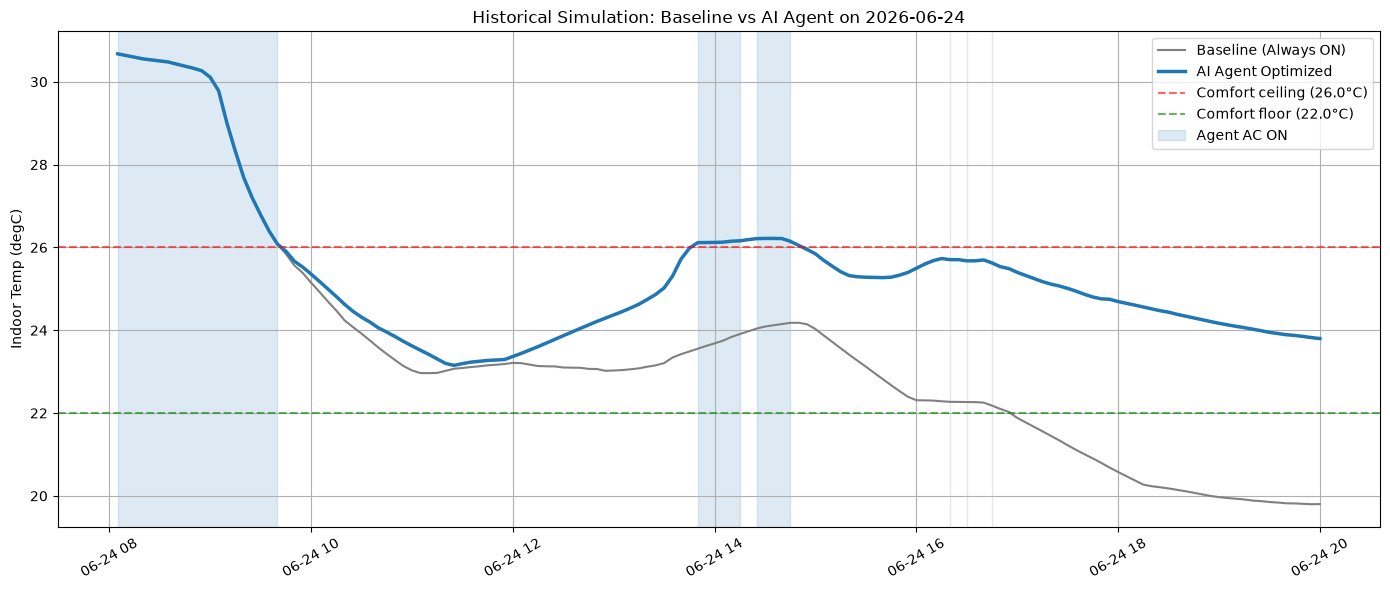

Day 1 Summary (2026-06-24): Agent ran AC for 2.8 hrs vs Baseline 12.0 hrs. (Saved 76.4% runtime)



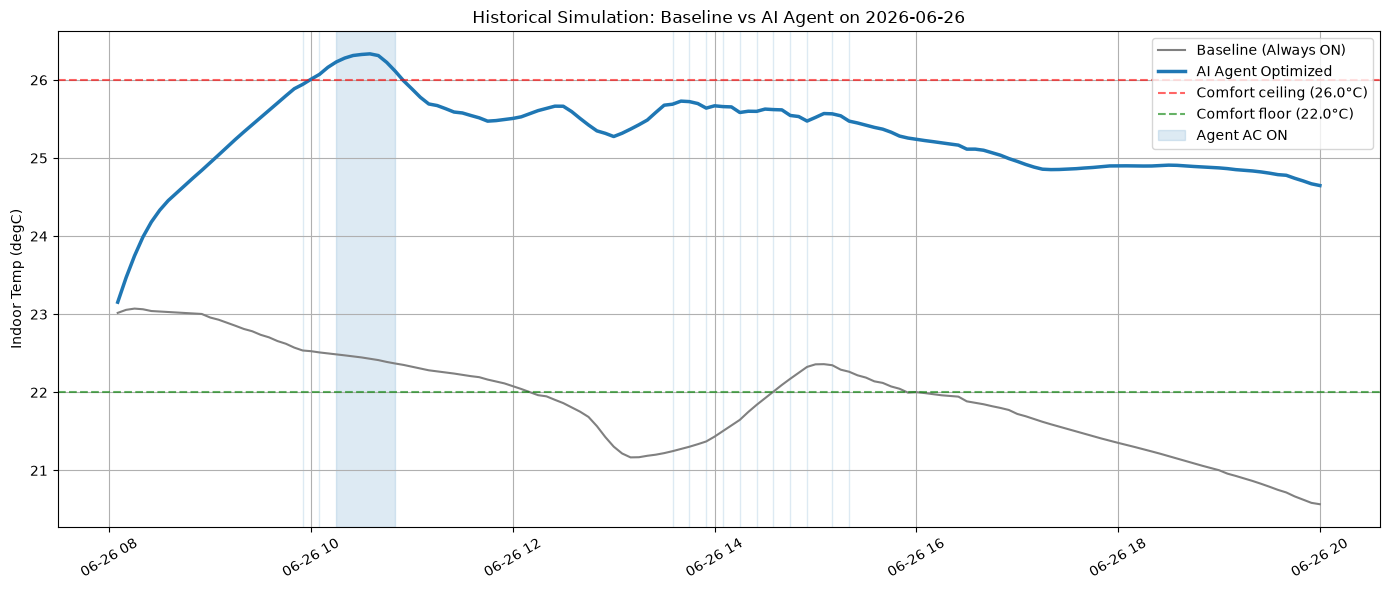

Day 2 Summary (2026-06-26): Agent ran AC for 1.8 hrs vs Baseline 12.0 hrs. (Saved 85.4% runtime)



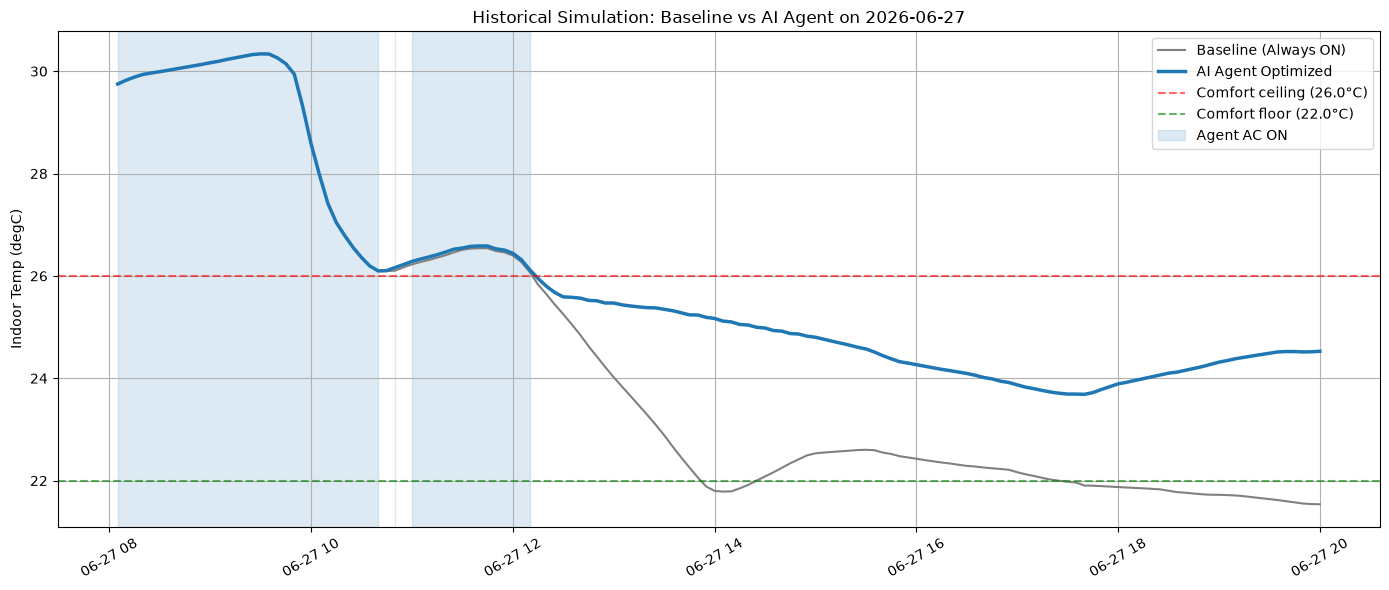

Day 3 Summary (2026-06-27): Agent ran AC for 4.0 hrs vs Baseline 12.0 hrs. (Saved 66.7% runtime)



In [19]:
import matplotlib.pyplot as plt
import pandas as pd

print("Scanning historical training data for more occupied days to visualize...")

# 1. Ensure the training data has the calendar columns needed for the scanner
df_train['Hour'] = df_train['Datetime'].dt.hour
df_train['DayName'] = df_train['Datetime'].dt.day_name()

# 2. Extract the valid occupied windows from the TRAINING set
train_day_windows = get_occupied_day_windows(df_train, NO_CLASS_DAYS, OCCUPIED_HOUR_START, OCCUPIED_HOUR_END)

print(f"Found {len(train_day_windows)} occupied days in historical data. Plotting up to 3 days...\n")

# 3. We will plot a maximum of 3 days so we don't flood your notebook with graphs
days_to_plot = min(3, len(train_day_windows))

for i in range(days_to_plot):
    d, start_idx, horizon = train_day_windows[i]
    
    # 4. Run the Dual-Track Simulation for this specific historical day
    day_res = simulate_agent_vs_baseline(env_model, agent_model, df_train, start_idx, horizon)
    sub = pd.DataFrame(day_res)
    
    # 5. Plot the result
    plt.figure(figsize=(14, 6))
    
    # Baseline (Grey) and Agent (Blue)
    plt.plot(sub["Datetime"], sub["Baseline_Temp"], color="gray", label="Baseline (Always ON)")
    plt.plot(sub["Datetime"], sub["Optimized_Temp"], color="tab:blue", linewidth=2.5, label="AI Agent Optimized")
    
    # Target Comfort Zone
    plt.axhline(COMFORT_MAX_C, color="red", linestyle="--", alpha=0.6, label=f"Comfort ceiling ({COMFORT_MAX_C}°C)")
    plt.axhline(COMFORT_MIN_C, color="green", linestyle="--", alpha=0.6, label=f"Comfort floor ({COMFORT_MIN_C}°C)")
    
    # Shading for when Agent turned AC ON
    plt.fill_between(sub["Datetime"], 0, 1, where=(sub["Optimized_AC"] == 1),
                     transform=plt.gca().get_xaxis_transform(), color="tab:blue", alpha=0.15, label="Agent AC ON")
    
    # Aesthetics
    plt.title(f"Historical Simulation: Baseline vs AI Agent on {d}")
    plt.ylabel("Indoor Temp (degC)")
    plt.xticks(rotation=30)
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Print a quick summary of the Agent's performance for this specific day
    agent_runtime = sub["Optimized_AC"].sum() * SAMPLE_MINUTES / 60
    base_runtime = sub["Baseline_AC"].sum() * SAMPLE_MINUTES / 60
    savings = (1 - agent_runtime / base_runtime) * 100 if base_runtime else 0
    print(f"Day {i+1} Summary ({d}): Agent ran AC for {agent_runtime:.1f} hrs vs Baseline {base_runtime:.1f} hrs. (Saved {savings:.1f}% runtime)\n")